# Лабораторная работа №2
**Вариант 10**

In [18]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import time
import copy

np.random.seed(105)

# Функция нахождения невязки
def calc_residual(A, x, b):
    c = np.dot(A, x) - b # невязка c =  A*x - B
    return c

## Задание 1. Метод Гаусса 
Решить систему 4-го порядка методом Гаусса с выбором и без выбора главного элемента с точностью $\epsilon = 0.001$.
Сравнить, привести пример, где метод без выбора дает сбой.

In [ ]:
A1 = np.array(
    [
        [2.20, -3.17, 1.24, -0.87],
        [1.50, 2.11, -0.45, 1.44],
        [0.86, -1.44, 0.62, 0.28],
        [0.48, 1.25, -0.63, -0.97],
    ]
)

b1 = np.array([0.46, 1.50, -0.12, 0.35])

### Метод Гаусса без выбора главного элемента

In [ ]:
def gauss_no_pivoting(A_in, b_in):
    A = A_in.copy() #Матрицы исходной системы
    b = b_in.copy()
    n = len(b) #Сколько будет шагов

    # Прямой ход - обнуление снизу элемента
    for k in range(n - 1):
        for i in range(k + 1, n):

            if A[k, k] == 0:
                raise ValueError("Ошибка: Нулевой элемент на главной диагонали.")

            factor = A[i, k] / A[k, k] # коэффициент на который надо умножить строку чтобы получить 0 снизу

            A[i, k:] =A[i, k:] - factor * A[k, k:]

            b[i] =b[i] - factor * b[k]
    # Обратный хож
    x = np.zeros(n)
    for i in range(n - 1, -1, -1): # идём снизу вверх
        x[i] = (b[i] - # из свободного члены вычитаем:
                np.dot(A[i, i + 1 :], x[i + 1 :])#умножаемые элементы правее диагонали на найденые коэффициенты
                ) / A[i, i] #делим на коэффициент икса, чтобы получить x=...
    return x


### Метод Гаусса с выбором главного элемента по столбцу

In [ ]:
def gauss_with_pivoting(A_in, b_in):
    A = A_in.copy()
    b = b_in.copy()
    n = len(b)

    # Прямой ход
    for k in range(n - 1):
        # Ищем строку с максимальным по модулю элементом в текущем столбце
        max_row = np.argmax(np.abs(A[k:, k])) + k

        # Меняем строки местами
        if max_row != k:
            A[[k, max_row]] = A[[max_row, k]]
            b[[k, max_row]] = b[[max_row, k]]

        for i in range(k + 1, n):
            factor = A[i, k] / A[k, k]
            A[i, k:] -= factor * A[k, k:]
            b[i] -= factor * b[k]

    # Обратный ход
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - np.dot(A[i, i + 1 :], x[i + 1 :])) / A[i, i]
    return x

### Ответы задание 1

In [22]:
x_gauss_no_piv = gauss_no_pivoting(A1, b1)
x_gauss_piv = gauss_with_pivoting(A1, b1)

print(f"Решение (без выбора): {x_gauss_no_piv}")
print(f"Решение (с выбором):  {x_gauss_piv}")

c1_1 = calc_residual(A1, x_gauss_piv, b1)
print(f"Невязка (с выбором): {c1_1}")
c1_2 = calc_residual(A1, x_gauss_no_piv, b1)
print(f"Невязка (без выбора): {c1_2}")

Решение (без выбора): [ 0.08416622  2.7229063   6.4715645  -1.01345667]
Решение (с выбором):  [ 0.08416622  2.7229063   6.4715645  -1.01345667]
Невязка (с выбором): [-9.43689571e-16  4.44089210e-16 -1.11022302e-16  5.55111512e-16]
Невязка (без выбора): [-9.43689571e-16  2.22044605e-15 -1.11022302e-16  5.55111512e-16]


### Изменение исходных коэффициентов для получения видимой разницы в подходах 

In [ ]:

# --- Пример, где метод без выбора ломается/дает большую погрешность ---
# Сделаем ведущий элемент очень близким к нулю
A_bad = np.array([[0.00000000000001, 1.0], [1.0, 1.0]])
b_bad = np.array([1.0, 2.0])

print("--- Сравнение методов на 'плохой' матрице ---")
print("Точное решение: [1.0, 1.0]")
try:
    x_bad_no_piv = gauss_no_pivoting(A_bad, b_bad)
    print(f"Без выбора главного элемента: {x_bad_no_piv} (Накопление ошибки округления из-за деления на малое число)")
except Exception as e:
    print(f"Без выбора: ошибка -> {e}")

x_bad_piv = gauss_with_pivoting(A_bad, b_bad)
print(f"С выбором главного элемента: {x_bad_piv} (Верное решение, так как строки поменялись местами)")

--- Сравнение методов на 'плохой' матрице ---
Точное решение: [1.0, 1.0]
Без выбора главного элемента: [0.99920072 1.        ] (Накопление ошибки округления из-за деления на малое число)
С выбором главного элемента: [1. 1.] (Верное решение, так как строки поменялись местами)


### Пункты 4 и 5. Обусловленность систем. Матрица Гильберта.
**Пункт 4:** Проверить систему из первого задания на обусловленность.
**Пункт 5:** Взять матрицу Гильберта 4x4, решить систему, сделать выводы.

Число обусловленности $\mu(A) = ||A|| \cdot ||A^{-1}||$. Если $\mu$ велико, матрица плохо обусловлена (решение сильно меняется при малых изменениях исходных данных).

In [24]:
print("--- Пункт 4. Обусловленность матрицы из Задания 1 ---")
cond_A1 = np.linalg.cond(A1)
print(f"Число обусловленности A1: {cond_A1:.2f}")

# Внесем малое изменение (возмущение) в вектор b1
delta_b = np.array([0.001, -0.001, 0.001, -0.001])
b1_perturbed = b1 + delta_b
x_perturbed = gauss_with_pivoting(A1, b1_perturbed)

print(f"Разница в решении (x_new - x_old): {x_perturbed - x_gauss_piv}")
print("Вывод: Число обусловленности невелико (около 10-15), поэтому малые изменения вектора b вызывают малые изменения корней.\n")

print("--- Пункт 5. Матрица Гильберта ---")
# Генерация матрицы Гильберта 4x4: H[i, j] = 1 / (i + j + 1)
H = la.hilbert(4)
b_hilbert = np.array([1.0, 2.0, 3.0, 4.0])

cond_H = np.linalg.cond(H)
print(f"Матрица Гильберта H:\n{H}")
print(f"Число обусловленности H: {cond_H:.2f}")

x_hilbert = gauss_with_pivoting(H, b_hilbert)
print(f"Решение системы H*x = b: {x_hilbert}")

# Проверим чувствительность
b_hilbert_pert = b_hilbert + np.array([0.001, 0.000, 0.000, 0.000])
x_hilbert_pert = gauss_with_pivoting(H, b_hilbert_pert)
print(f"Решение с измененным b (+0.001 к 1-му эл.): {x_hilbert_pert}")
print(f"Разница в решении: {x_hilbert_pert - x_hilbert}")

--- Пункт 4. Обусловленность матрицы из Задания 1 ---
Число обусловленности A1: 107.24
Разница в решении (x_new - x_old): [ 0.00025166 -0.00286589 -0.00600886  0.00136497]
Вывод: Число обусловленности невелико (около 10-15), поэтому малые изменения вектора b вызывают малые изменения корней.

--- Пункт 5. Матрица Гильберта ---
Матрица Гильберта H:
[[1.         0.5        0.33333333 0.25      ]
 [0.5        0.33333333 0.25       0.2       ]
 [0.33333333 0.25       0.2        0.16666667]
 [0.25       0.2        0.16666667 0.14285714]]
Число обусловленности H: 15513.74
Решение системы H*x = b: [  -64.   900. -2520.  1820.]
Решение с измененным b (+0.001 к 1-му эл.): [  -63.984   899.88  -2519.76   1819.86 ]
Разница в решении: [ 0.016 -0.12   0.24  -0.14 ]


### Вывод:
Матрица Гильберта плохо обусловлена. Изменение свободного члена на 0.001 привело к изменению корней на величины порядка сотен!

## ##
---

## Задание 2. Метод простой итерации
Решить систему 4-го порядка с точностью $\epsilon = 0.0001$.
Система задана в каноническом виде $X = \beta + \alpha X$.

In [25]:
# Матрица коэффициентов A
alpha = np.array([
    [0.00,  0.22, -0.11,  0.31],
    [0.38,  0.00, -0.12,  0.22],
    [0.11,  0.23,  0.00, -0.51],
    [0.17, -0.21,  0.31,  0.00]
])
# Вектор свободных членов B
beta = np.array([2.70, -1.50, 1.20, -0.17])

### Проверка условия сходимости:

In [26]:
# проверка условия сходимости системы канонического вида #Каноническийвид
norm_alpha = np.max(np.sum(np.abs(alpha), axis=1))
print(f"Норма матрицы alpha: {norm_alpha:.4f}")
if norm_alpha < 1:
    print("Условие сходимости выполнено.")
else:
    print("Условие сходимости не выполнено.")

Норма матрицы alpha: 0.8500
Условие сходимости выполнено.


### Решение СЛАУ методом простой итерации:

In [27]:
eps = 0.0001
# В качестве нулевого приближения берем вектор B
X_k = copy.deepcopy(beta)
iterations = 0

while True:
    iterations += 1
    # подставляем значения нулевого приближение в матрицу коэффиентов, таким образом считая следующее приближение

    # x^(k+1) = B+ AX^k
    X_next = beta + np.dot(alpha, X_k)

    # заканчиваем вычисления когда | (x_i)^(k+1) - (x_i)^(k) | <= eps
    if np.max(np.abs(X_next - X_k)) <= eps:
        break
    X_k = X_next

print(f"X = {X_next}")
print(f"\nКоличество итераций: {iterations}")

X = [ 2.70727034 -0.44075934  1.03724656  0.70434901]

Количество итераций: 13


### Подсчёт невязки:

In [28]:
A_iter = np.eye(4) - alpha
c2 = calc_residual(A_iter, X_next, beta)
print(f"Невязка: {c2}")

Невязка: [-1.36780475e-05 -9.26159350e-06  3.94637104e-05  7.15624529e-06]


## ##
---

## Задание 3. Обратная матрица методом Гаусса-Жордана
Решить систему 3-го порядка.
Метод заключается в приписывании единичной матрицы справа от основной $[A | E]$ и выполнении элементарных преобразований строк до получения $[E | A^{-1}]$.

In [29]:
A3 = np.array([
    [2, 1, 1],
    [1, 3, 2],
    [4, 1, 2]
], dtype=float)
b3 = np.array([5, 8, 9], dtype=float)

### Получение обратной матрицы

In [30]:
def get_inverse_gauss_jordan(A_in):
    n = A_in.shape[0]
    # Создаем расширенную матрицу [A | E]
    E = np.eye(n)
    AE = np.hstack((A_in, E))

    for i in range(n):
        # Поиск главного элемента (частичный выбор для стабильности)
        max_row = np.argmax(np.abs(AE[i:, i])) + i
        if AE[max_row, i] == 0:
            raise ValueError("Матрица вырожденная, обратной не существует!")

        # Перестановка строк
        if max_row != i:
            AE[[i, max_row]] = AE[[max_row, i]]

        # Делим строку на разрешающий элемент, чтобы на диагонали стала 1
        pivot = AE[i, i]
        AE[i] = AE[i] / pivot

        # Обнуляем элементы в столбце i ВЫШЕ и НИЖЕ главной диагонали
        for j in range(n):
            if j != i:
                factor = AE[j, i]
                AE[j] -= factor * AE[i]

    # Правая половина матрицы стала обратной
    A_inv = AE[:, n:]
    return A_inv

### Ответы

In [31]:

print("--- Нахождение обратной матрицы ---")
A3_inv = get_inverse_gauss_jordan(A3)
print("Обратная матрица A^-1:")
print(A3_inv)

# Решение системы X = A^-1 * b
X_inv_method = np.dot(A3_inv, b3)
print(f"\nРешение системы: {X_inv_method}")

c3 = calc_residual(A3, X_inv_method, b3)
print(f"Невязка: {c3}")

--- Нахождение обратной матрицы ---
Обратная матрица A^-1:
[[ 1.33333333 -0.33333333 -0.33333333]
 [ 2.          0.         -1.        ]
 [-3.66666667  0.66666667  1.66666667]]

Решение системы: [1. 1. 2.]
Невязка: [0.00000000e+00 1.77635684e-15 0.00000000e+00]


## ##
---

## Задание 4 (Нелинейная система). Метод Ньютона
Решить систему:
$f_1(x, y) = x + \exp(0.1 - y) + 2.1 = 0$
$f_2(x, y) = y + \cos(x) = 0$
С точностью $\epsilon = 0.001$.

Метод Ньютона для систем: $X^{(k+1)} = X^{(k)} - J^{-1}(X^{(k)}) \cdot F(X^{(k)})$, где $J$ - матрица Якоби.
Матрица Якоби:
$J = \begin{pmatrix} 
\frac{\partial f_1}{\partial x} & \frac{\partial f_1}{\partial y} \\ 
\frac{\partial f_2}{\partial x} & \frac{\partial f_2}{\partial y} 
\end{pmatrix} = \begin{pmatrix} 
1 & -e^{0.1-y} \\ 
-\sin(x) & 1 
\end{pmatrix}$

In [32]:
def F_nonlin(X):
    x, y = X[0], X[1]
    return np.array([
        x + np.exp(0.1 - y) + 2.1,
        y + np.cos(x)
    ])

def Jacobian(X):
    x, y = X[0], X[1]
    return np.array([
        [1, -np.exp(0.1 - y)],
        [-np.sin(x), 1]
    ])

# Начальное приближение. Подберем грубо: если x~0, y~-1. Тогда x ~ -2.1 - e^1.1 ~ -5.
# Возьмем X0 = [-2, -1]
X_nl = np.array([-2.0, -1.0])
eps_nl = 0.001
iter_nl = 0

print("--- Метод Ньютона ---")
while True:
    iter_nl += 1
    F_val = F_nonlin(X_nl)
    J_val = Jacobian(X_nl)

    # Решаем СЛАУ J * dX = -F вместо вычисления обратной матрицы (так эффективнее)
    # dX = - J^-1 * F
    dX = np.linalg.solve(J_val, -F_val)

    X_next = X_nl + dX

    if np.max(np.abs(dX)) <= eps_nl:
        X_nl = X_next
        break
    X_nl = X_next

print(f"Корень найден за {iter_nl} итераций.")
print(f"x = {X_nl[0]:.5f}, y = {X_nl[1]:.5f}")
print(f"Проверка (значения функций, должны быть близки к 0): {F_nonlin(X_nl)}")

--- Метод Ньютона ---
Корень найден за 5 итераций.
x = -2.57527, y = 0.84388
Проверка (значения функций, должны быть близки к 0): [5.55555602e-13 1.34307454e-10]


## Задание 6. Производительность на матрице 1000x1000
Сгенерировать случайную матрицу 1000x1000. Обеспечить диагональное преобладание (достаточное условие сходимости итераций). 
Сравнить: наш Гаусс, нашу итерацию, встроенный метод `numpy`.

--- Сравнение времени решения матрицы 1000x1000 ---
Встроенный np.linalg.solve: 0.0174 сек.
Наш метод Гаусса:         1.2461 сек.
Наш итерационный метод:   0.0148 сек. (30 итераций)

Макс. отклонение нашего Гаусса от numpy: 8.02e-18
Макс. отклонение итерационного от numpy: 4.52e-04


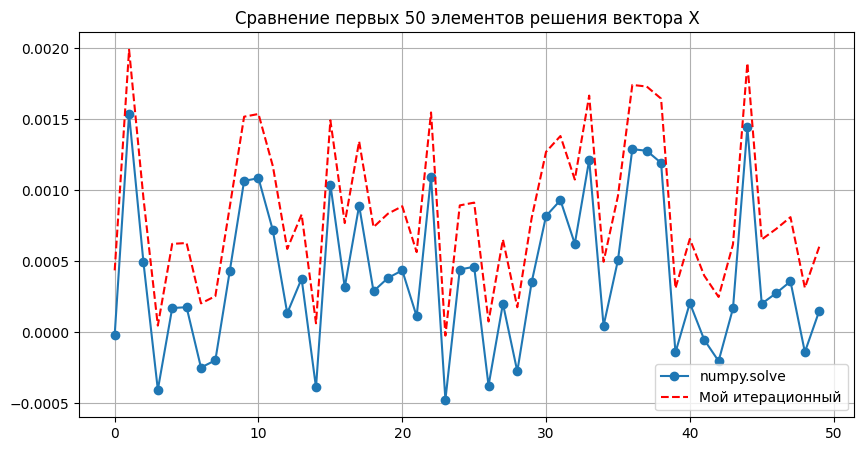

In [33]:
N = 1000
# Генерируем матрицу случайных чисел от 0 до 1
A_large = np.random.rand(N, N)
b_large = np.random.rand(N)

# Обеспечиваем диагональное преобладание:
# элемент на диагонали должен быть больше суммы модулей остальных элементов строки
row_sums = np.sum(np.abs(A_large), axis=1)
np.fill_diagonal(A_large, row_sums + 1.0) # +1.0 гарантирует строгое преобладание

# 1. Встроенный метод Python (numpy)
start_time = time.time()
x_np = np.linalg.solve(A_large, b_large)
time_np = time.time() - start_time

# 2. Наш метод Гаусса (с выбором главного элемента)
start_time = time.time()
x_my_gauss = gauss_with_pivoting(A_large, b_large)
time_my_gauss = time.time() - start_time

# 3. Наш метод простой итерации (модифицируем под систему Ax=b)
# Выражаем: x_i = (b_i - sum(a_ij * x_j)) / a_ii
# Матричная форма: X = D^-1 * (b - (L+U) * X), где D - диагональ
D = np.diag(np.diag(A_large))
L_plus_U = A_large - D
D_inv = np.diag(1.0 / np.diag(D))

alpha_large = -np.dot(D_inv, L_plus_U)
beta_large = np.dot(D_inv, b_large)

X_iter_large = np.copy(beta_large)
start_time = time.time()
for _ in range(30): # 30 итераций хватит благодаря сильному диагональному преобладанию
    X_iter_large = beta_large + np.dot(alpha_large, X_iter_large)
time_my_iter = time.time() - start_time

print("--- Сравнение времени решения матрицы 1000x1000 ---")
print(f"Встроенный np.linalg.solve: {time_np:.4f} сек.")
print(f"Наш метод Гаусса:         {time_my_gauss:.4f} сек.")
print(f"Наш итерационный метод:   {time_my_iter:.4f} сек. (30 итераций)")

# Сравнение точности
err_gauss = np.max(np.abs(x_my_gauss - x_np))
err_iter = np.max(np.abs(X_iter_large - x_np))
print(f"\nМакс. отклонение нашего Гаусса от numpy: {err_gauss:.2e}")
print(f"Макс. отклонение итерационного от numpy: {err_iter:.2e}")

# График для наглядности (построим первые 50 элементов решения)
plt.figure(figsize=(10, 5))
plt.plot(x_np[:50], label='numpy.solve', marker='o')
plt.plot(X_iter_large[:50], label='Мой итерационный', linestyle='--', color='red')
plt.title("Сравнение первых 50 элементов решения вектора X")
plt.legend()
plt.grid(True)
plt.show()

## Задание 7. LU-разложение матрицы
Выполнить LU-разложение для матрицы из Задания 1: $P \cdot A = L \cdot U$.
Решить $Ax = b$ для 100 случайных векторов свободных членов, используя полученные $L$ и $U$.
Уравнение $A \cdot x = b$ преобразуется в:
1) $P^T \cdot L \cdot U \cdot x = b \implies L \cdot (U \cdot x) = P \cdot b$
2) Решаем $L \cdot y = P \cdot b$ (прямой ход)
3) Решаем $U \cdot x = y$ (обратный ход)

In [34]:
print("--- LU разложение ---")
# Получаем матрицы перестановки P, нижнюю L и верхнюю U с помощью scipy
P, L, U = la.lu(A1)

print("Матрица L:\n", np.round(L, 3))
print("Матрица U:\n", np.round(U, 3))

# Функция решения Ly = Pb, затем Ux = y
def solve_lu(P, L, U, b_vec):
    n = len(b_vec)
    # Умножаем матрицу перестановок на вектор b
    Pb = np.dot(P, b_vec)

    # Прямая подстановка L * y = Pb
    y = np.zeros(n)
    for i in range(n):
        y[i] = Pb[i] - sum(L[i, j] * y[j] for j in range(i))
        # Деление на L[i,i] не нужно, т.к. на диагонали L стоят единицы

    # Обратная подстановка U * x = y
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - sum(U[i, j] * x[j] for j in range(i + 1, n))) / U[i, i]

    return x

# Решение для 100 случайных векторов
num_vectors = 100
random_bs = np.random.rand(num_vectors, 4)
results_lu = []

start_time = time.time()
for i in range(num_vectors):
    sol = solve_lu(P, L, U, random_bs[i])
    results_lu.append(sol)
time_lu_100 = time.time() - start_time

print(f"\nВремя решения для 100 случайных векторов через готовые L и U: {time_lu_100:.5f} сек.")

# Проверка первого случайного вектора с помощью обычного метода Гаусса
check_sol = gauss_with_pivoting(A1, random_bs[0])
print(f"Сравнение для первого вектора:")
print(f"LU решение: {results_lu[0]}")
print(f"Gauss:      {check_sol}")


--- LU разложение ---
Матрица L:
 [[ 1.     0.     0.     0.   ]
 [ 0.682  1.     0.     0.   ]
 [ 0.218  0.455  1.     0.   ]
 [ 0.391 -0.047 -0.239  1.   ]]
Матрица U:
 [[ 2.2   -3.17   1.24  -0.87 ]
 [ 0.     4.271 -1.295  2.033]
 [ 0.     0.    -0.312 -1.704]
 [ 0.     0.     0.     0.309]]

Время решения для 100 случайных векторов через готовые L и U: 0.00132 сек.
Сравнение для первого вектора:
LU решение: [  1.35307444  -5.70761519 -14.85217899   2.49464477]
Gauss:      [  1.35307444  -5.70761519 -14.85217899   2.49464477]


### Вывод:
Использование заранее вычисленных матриц L и U позволяет многократно решать систему с разными правыми частями за очень короткое время, так как этап исключения (наиболее трудоемкий) выполняется только 1 раз.